# Lab 05 — Best-server and population KPIs

HTZ population analysis analogue.

{'total_population': 16868307.868797302, 'served_population': 6058084.904045105, 'unserved_population': 10810222.964752197, 'coverage_percent': 35.91, 'pixels_total': 160000, 'pixels_covered': 36723}


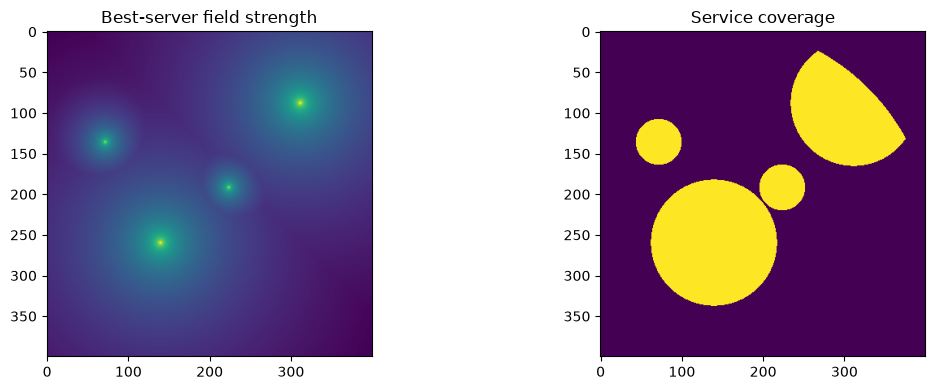

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
from broadcast_planner.core.regions import DEFAULT_REGION, EXAMPLES_DIR
from broadcast_planner.core.grids import read_raster, make_grid
from broadcast_planner.core.sites import load_sites
from broadcast_planner.dvb_t.models import DvbTConfig
from broadcast_planner.dvb_t.coverage import run_dvb_t_coverage

dem, _ = read_raster(DEFAULT_REGION.dem_path())
clutter, _ = read_raster(DEFAULT_REGION.clutter_path())
population, _ = read_raster(DEFAULT_REGION.population_path())
grid = make_grid(DEFAULT_REGION, resolution_m=250.0)
sites = load_sites(EXAMPLES_DIR / 'sites.yaml')
result = run_dvb_t_coverage(sites, grid, dem, clutter, population, DvbTConfig())
print(result.population_stats)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(result.best_field_dbuv_m, origin='upper'); ax[0].set_title('Best-server field strength')
ax[1].imshow(result.service_coverage, origin='upper'); ax[1].set_title('Service coverage')
plt.tight_layout()